In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sp
import statsmodels as sm
from matplotlib import pyplot as plt
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from patsy import dmatrix

### **1. ***Life expectancy*** function.**

In [47]:
def reshaped_life_expectancy():

    # Loading the dataset.
    path_to_file = '/Users/angelina/Desktop/USC/Math 446/dataset/new_life_expectancy.csv'
    X = pd.read_csv(path_to_file)
    
    # Fixing columns names.=
    X.columns = X.columns\
        .str.strip()\
        .str.replace(pat="  ", repl=" ")\
        .str.replace(pat="[' '-/]", repl="_", regex=True)\
        .str.lower()
    
    # Discarding rows with missing life expectancy values.
    X = X.dropna(axis=0, subset=['life_expectancy'])
    
    # Data wrangling.
    X['status'] = np.where(X['status'] == 'Developing', 0, 1) # Turning "status" into a dummy variable.
    
    X = X.astype({'under_five_deaths': np.float64, # Resetting the data types of a few features
                  'infant_deaths': np.float64,
                  'measles': np.float64,
                  'status': np.float64,
                  'year': np.float64})
    
    # Treating some zero values as nan values.
    slicing = X.columns.difference(['status', 'country', 'year'])
    X.loc[:, slicing] = X.loc[:, slicing].where(X.loc[:, slicing] > 0, np.nan)
    
    # Log transform.
    slicing = ['adult_mortality', 'infant_deaths', 'percentage_expenditure',
               'measles', 'under_five_deaths', 'hiv_aids', 'gdp', 
               'population', 'thinness_1_19_years', 'thinness_5_9_years']
    
    X.loc[:, slicing] = np.log(X.loc[:, slicing])
    
    X = X.rename(columns={'income_composition_of_resources': 'icr',
                          'percentage_expenditure': 'per_expend'})
    
    return X

In [48]:
reshaped_life_expectancy()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,per_expend,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,icr,schooling
0,Afghanistan,2015.0,0.0,65.0,5.572154,4.127134,0.01,4.266611,65.0,7.050989,...,6.0,8.16,65.0,-2.302585,6.370345,17.334091,2.844909,2.850707,0.479,10.1
1,Afghanistan,2014.0,0.0,59.9,5.602119,4.158883,0.01,4.297606,62.0,6.198479,...,58.0,8.18,62.0,-2.302585,6.417870,NaN,2.862201,2.862201,0.476,10.0
2,Afghanistan,2013.0,0.0,59.9,5.590987,4.189655,0.01,4.293458,64.0,6.063785,...,62.0,8.13,64.0,-2.302585,6.448486,17.272826,2.873565,2.873565,0.470,9.9
3,Afghanistan,2012.0,0.0,59.5,5.605802,4.234107,0.01,4.359068,67.0,7.932721,...,67.0,8.52,67.0,-2.302585,6.507217,NaN,2.884801,2.890372,0.463,9.8
4,Afghanistan,2011.0,0.0,59.2,5.616771,4.262680,0.01,NaN,68.0,8.010692,...,68.0,7.87,68.0,-2.302585,NaN,NaN,2.901422,2.901422,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,Zimbabwe,2004.0,0.0,44.3,6.583409,3.295837,4.36,NaN,68.0,3.433987,...,67.0,7.13,65.0,3.514526,6.118904,16.363197,2.240710,2.240710,0.407,9.2
2924,Zimbabwe,2003.0,0.0,44.5,6.572283,3.258097,4.06,NaN,7.0,6.905753,...,7.0,6.52,68.0,3.602777,6.116667,16.351894,2.282382,2.292535,0.418,9.5
2925,Zimbabwe,2002.0,0.0,44.8,NaN,3.218876,4.43,NaN,73.0,5.717028,...,73.0,6.53,71.0,3.683867,NaN,NaN,0.182322,0.262364,0.427,10.0
2926,Zimbabwe,2001.0,0.0,45.3,6.530878,3.218876,1.72,NaN,76.0,6.270988,...,76.0,6.16,75.0,3.740048,6.307346,16.330475,0.470004,0.530628,0.427,9.8


### **2. ***data preprocessing*** function.**

In [49]:
def data_preprocessing(X_train,
                       X_test,
                       y_train,
                       y_test,
                       regressors=None,
                       interaction=False,
                       use_pca=False, 
                       pcs=None):

    # Treating some zero values as nan values...
    slicing = ['infant_deaths', 'per_expend', 'measles', 'under_five_deaths', 'icr'] # features with lots of zeros
    X_train.loc[:, slicing] = X_train.loc[:, slicing].replace(to_replace=0, value=np.nan)
    
    # Use the latest non-missing value to forward-fill / backward-fill missing values in X_train.
    X_train = X_train.sort_values(by=['status', 'country', 'year'], ascending=[True, True, True])
    slicing = X_train.columns.difference(['country'])
    X_train.loc[:, slicing] = X_train.groupby(['country']).transform(lambda x: x.ffill())
    X_train.loc[:, slicing] = X_train.groupby(['country']).transform(lambda x: x.bfill())

    # Then use X_train to infer some of the missing values in X_test. (avoid data leakage)
    concat_X = pd.concat([X_train.copy(), X_test.copy()])\
        .sort_values(by=['status', 'country', 'year'], ascending=[True, True, True])
    slicing = concat_X.columns.difference(['country'])
    concat_X.loc[:, slicing] = concat_X.groupby(['country']).transform(lambda x: x.ffill())
    concat_X.loc[:, slicing] = concat_X.groupby(['country']).transform(lambda x: x.bfill())
    X_test = concat_X.loc[X_test.index, :]

    y_train = y_train.loc[X_train.index] # input and output must be aligned.
    y_test = y_test.loc[X_test.index]
    
    # Use KNN to infer missing values (must exclude 'population', 'country' from this process)
    drop_features = ['population', 'country']
    X_train_knn = X_train.drop(columns = drop_features)
    X_test_knn = X_test.drop(columns = drop_features)

    scaler = StandardScaler()
    scaler.fit(X_train_knn)
    X_train_rescaled = scaler.transform(X_train_knn)
    X_test_rescaled = scaler.transform(X_test_knn)

    #5 is a good value 
    knn_imputer = KNNImputer(n_neighbors=5, weights = 'distance', metric='nan_euclidean')
    knn_imputer.fit(X_train_rescaled)

    X_train.loc[:, X_train_knn.columns] = scaler.inverse_transform(knn_imputer.transform(X_train_rescaled))
    X_test.loc[:, X_test_knn.columns] = scaler.inverse_transform(knn_imputer.transform(X_test_rescaled))
    
    # Discarding "population" and "country".
    slicing = X_train.columns.difference(['population', 'country'])
    X_train = X_train.loc[:, slicing]
    X_test = X_test.loc[:, slicing]
    
    # Feature selection.
    if (regressors != None):
        if ((interaction == True) & ('status' not in regressors)):
            regressors.extend(['status'])
        
        X_train = X_train.loc[:, regressors]
        X_test = X_test.loc[:, regressors]    
        regressors = X_train.columns.tolist()

    # Interaction terms (ex, creating status - 0 or 1)
    if (interaction == True):
        #created two interaction terms: status x gdp and status x hiv_aids
        variables = ' + '.join(regressors)+ ' + status:gdp + status:hiv_aids' 
        X_train = dmatrix(variables, X_train, return_type='dataframe')
        X_test = dmatrix(variables, X_test, return_type='dataframe')
        regressors = X_train.columns.tolist()
        
    # PCA transformation
    if (use_pca == True):
        scaler = StandardScaler()
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)
        
        pca = PCA()
        pca.fit(X_train)
        X_train = pca.transform(X_train)
        X_test = pca.transform(X_test)

        # Feature selection (pcs)
        if (pcs != None):
            X_train = X_train[:, pcs]
            X_test = X_test[:, pcs]
            regressors = pcs
    
    return X_train, X_test, y_train, y_test, regressors

In [50]:
X = reshaped_life_expectancy()
y = X['life_expectancy']
X = X.drop(columns=['life_expectancy'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.35, random_state=12345)

data_preprocessing(X_train,
                   X_test,
                   y_train,
                   y_test,
                   interaction=False,
                   regressors=['status', 'hiv_aids', 'gdp', 'icr'],
                   use_pca=False,
                   pcs=[0, 1, 2])

(      status  hiv_aids        gdp       icr
 15       0.0 -2.302585   5.235622  0.338000
 14       0.0 -2.302585   5.235622  0.340000
 13       0.0 -2.302585   5.235622  0.341000
 12       0.0 -2.302585   5.291940  0.373000
 11       0.0 -2.302585   5.389717  0.381000
 ...      ...       ...        ...       ...
 2792     1.0 -2.302585  10.573324  0.896428
 2790     1.0 -2.302585  10.601191  0.901983
 2789     1.0 -2.302585  10.526571  0.903746
 2787     1.0 -2.302585  10.971181  0.918496
 2784     1.0 -2.302585  10.656993  0.902520
 
 [1903 rows x 4 columns],
       status  hiv_aids        gdp    icr
 2003     0.0 -2.302585   8.762143  0.725
 1705     0.0 -2.302585   6.940796  0.622
 1393     0.0 -2.302585  10.668874  0.787
 1559     0.0 -0.693147   5.934493  0.491
 2907     0.0  2.867899   6.538600  0.456
 ...      ...       ...        ...    ...
 411      0.0  0.916291   5.917075  0.325
 410      0.0  0.832909   5.917075  0.325
 1363     0.0  1.098612   7.052079  0.536
 1913     1.

## 3. Multilinear model

In [51]:
# F-statistic
def f_stat(y_true, residuals, p):
    rss = (residuals**2).sum()
    tss = ((y_true - y_true.mean())**2).sum()
    n = len(residuals)
    f_stat = ((tss - rss)/p)/(rss/(n-p-1))
    return f_stat

In [52]:
def multilinear_regression(X_train,
                           X_test,
                           y_train,
                           y_test,
                           regressors = None,
                           interaction = False,
                           use_pca = False,
                           pcs= None,
                           residuals =False):
    
    #Call data preprocessing function
    X_train, X_test, y_train, y_test,regressors = data_preprocessing(X_train,X_test,y_train,y_test,regressors=regressors,interaction=interaction,
        use_pca=use_pca,pcs=pcs)
    
    #training the model
    lm_model = LinearRegression()
    lm_model.fit(X=X_train, y=y_train)

    #making predictions for both y train and y test
    y_train_pred = lm_model.predict(X_train) #predicted y train using x train
    y_test_pred = lm_model.predict(X_test) # predicted y test using x test

    #collecting performance metrics
    #residuals 
    train_residuals = y_train - y_train_pred 
    test_residuals = y_test - y_test_pred
    
    #R^2 score
    train_R2_score = r2_score(y_true=y_train, y_pred=y_train_pred)
    test_R2_score = r2_score(y_true=y_test, y_pred=y_test_pred)
    
    #RMSE
    train_RMSE = root_mean_squared_error(y_true=y_train, y_pred=y_train_pred)
    test_RMSE = root_mean_squared_error(y_true=y_test, y_pred=y_test_pred)

    #F-stats
    train_f_stat = f_stat(y_true=y_train, residuals=train_residuals, p=len(regressors))
    test_f_stat = f_stat(y_true=y_test, residuals=test_residuals, p=len(regressors))

    #result
    results = {
        'train_R2_score': train_R2_score,
        'test_R2_score': test_R2_score,
        'train_RMSE': train_RMSE,
        'test_RMSE': test_RMSE,
        'train_f_stat': float(train_f_stat),
        'test_f_stat': float(test_f_stat),
        'regressors': regressors}

    if residuals:
        results['train_residuals'] = train_residuals
        results['test_residuals'] = test_residuals

    return results
                           

In [53]:
multilinear_regression(X_train,
                           X_test,
                           y_train,
                           y_test,
                           regressors = ['status', 'hiv_aids', 'gdp', 'icr'],
                           interaction = True,
                           use_pca = False,
                           pcs=[0, 1, 2])

{'train_R2_score': 0.8669532478726636,
 'test_R2_score': 0.8773627660543085,
 'train_RMSE': 3.4453611345356028,
 'test_RMSE': 3.382833404996953,
 'train_f_stat': 1764.0162235670707,
 'test_f_stat': 1039.3929482324932,
 'regressors': ['Intercept',
  'status',
  'hiv_aids',
  'gdp',
  'icr',
  'status:gdp',
  'status:hiv_aids']}

## 4. Model Validation

In [54]:
def model_validation_multi_regression(test_size=.35,
                                      split_seed=1234,
                                      cv_seed=54321,
                                      k=5,
                                      nbr_loops=10,
                                      regressors = None,
                                      interaction= False,
                                      use_pca = False,
                                      pcs = None,
                                      scores_only=False):
    #Loading dataset
    X = reshaped_life_expectancy()
    y = X['life_expectancy']
    X = X.drop(columns=['life_expectancy'])

    #splitting the data into train and test set
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_size,random_state = split_seed)

    #k-fold cross-validation evaluation of the model
    cv = RepeatedKFold(n_splits=k,random_state=cv_seed, n_repeats= nbr_loops)
    splitting = cv.split(X_train,y_train)

    kf_RMSEs = []
    kf_R2_scores = []
    kf_f_stats = []

    for train_index,test_index in splitting:

        X_subtrain = X_train.iloc[train_index,:].copy()
        X_subtest = X_train.iloc[test_index,:].copy()
        y_subtrain = y_train.iloc[train_index].copy()
        y_subtest = y_train.iloc[test_index].copy()

        results = multilinear_regression(X_train=X_subtrain, 
                                        X_test=X_subtest,
                                        y_train=y_subtrain,
                                        y_test=y_subtest,
                                        regressors = regressors,
                                        interaction = interaction,
                                        use_pca = use_pca,
                                        pcs = pcs,
                                        residuals = False)

        kf_RMSEs.append(results['test_RMSE'])
        kf_R2_scores.append(results['test_R2_score'])
        kf_f_stats.append(results['test_f_stat'])

    kf_R2_score = np.mean(kf_R2_scores)
    kf_RMSE = np.mean(kf_RMSEs)
    kf_f_stat = np.mean(kf_f_stats)

    #Evaluation on the testing dataset
    results = multilinear_regression(X_train=X_train, 
                                        X_test=X_test,
                                        y_train=y_train,
                                        y_test=y_test,
                                        regressors = regressors,
                                        interaction = interaction,
                                        use_pca = use_pca,
                                        pcs = pcs,
                                        residuals = True
                                    )
    
    test_RMSE = results['test_RMSE']
    test_R2_score = results['test_R2_score']
    test_f_stat = results['test_f_stat']
    train_residuals = results['train_residuals']
    test_residuals = results['test_residuals']
    fitted_regressors = results['regressors']
    train_RMSE = results['train_RMSE']
    
    # collecting all performance scores.
    if (scores_only):
        return {"kf_R2_score": kf_R2_score,
                "kf_RMSE": kf_RMSE,
                "kf_f_stat": kf_f_stat,
                "test_R2_score": test_R2_score,
                "test_RMSE": test_RMSE,
                "test_f_stat": test_f_stat,
                'regressors': fitted_regressors}
    
    else:
        print(f"regressors: {fitted_regressors}")
        print(f"k-fold R^2: {kf_R2_score}\nk-fold RMSE: {kf_RMSE}\nk-fold F-stat: {kf_f_stat}")
        print(f"Test R^2: {test_R2_score}\nTest RMSE: {test_RMSE}\nTest F-stat: {test_f_stat}\n")
        
        plt.rcParams["figure.figsize"] = [7, 2]
        plt.rcParams["figure.autolayout"] = True
        sns.histplot(x=train_residuals, stat='density', fill=True, alpha=0.5, color='cornflowerblue');
        sns.kdeplot(data=train_residuals, fill=True, alpha=0.5, color='cornflowerblue');
        sns.kdeplot(x=np.random.normal(scale=train_RMSE, size=100000), fill=True, alpha=0.3, color='green');    

regressors: ['Intercept', 'status', 'hiv_aids', 'gdp', 'icr', 'status:gdp', 'status:hiv_aids']
k-fold R^2: 0.8649104223853105
k-fold RMSE: 3.4913131261163484
k-fold F-stat: 343.4508802897968
Test R^2: 0.8762579934084759
Test RMSE: 3.34543376725246
Test F-stat: 1028.8160987332597



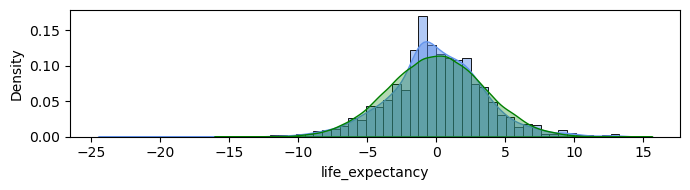

In [55]:
model_validation_multi_regression(test_size=.35,
                                      split_seed=1234,
                                      cv_seed=54321,
                                      k=5,
                                      nbr_loops=10,
                                      regressors = ['status', 'hiv_aids', 'gdp', 'icr'],
                                      interaction= True,
                                      use_pca = False,
                                      pcs = None,
                                      scores_only=False)

## Task 2: An optimized multilinear regression model without PCA

### Comprehensive approach

For the comprehensive approach, due to the computational cost of evaluating all possible combinations of regressors(since there are 19 regressors), I decided to select variables that showed strong correlation with life expectancy and tried combinations of the top ones.

In [56]:
from itertools import combinations

# Load dataset
X = reshaped_life_expectancy()
y = X['life_expectancy']
X = X.drop(columns=['life_expectancy'])

# Split train/test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.35, random_state=12345)

train_df = X_train.copy()
train_df = train_df.assign(life_expectancy=y_train)

#Look at the correlation between the predictors with life expectancy using the training data
corr_df = train_df.drop(columns=['country', 'population']).corrwith(train_df['life_expectancy'], numeric_only=True).abs().sort_values(ascending=False)

print(corr_df)

life_expectancy        1.000000
adult_mortality        0.934404
icr                    0.884871
hiv_aids               0.812106
gdp                    0.796543
schooling              0.775087
per_expend             0.764885
bmi                    0.711251
thinness_5_9_years     0.554508
thinness_1_19_years    0.543954
under_five_deaths      0.542011
status                 0.498489
infant_deaths          0.489579
diphtheria             0.460977
polio                  0.447396
alcohol                0.391481
measles                0.301891
hepatitis_b            0.253035
total_expenditure      0.225209
year                   0.170449
dtype: float64


In [57]:
top_features = {'adult_mortality','icr','hiv_aids','gdp','schooling','per_expend'} # these are the top 6 features

# generate all combinations
all_combinations = set()

for k in np.arange(2, 6):  
    for c in combinations(top_features, k):
        all_combinations.add(c)

all_combinations = tuple(all_combinations)

#run all models
res = [
    model_validation_multi_regression(
        k=5,
        nbr_loops=10,
        regressors=list(combination),
        interaction=False,
        use_pca=False,
        pcs=None,
        scores_only=True
    )
    for combination in all_combinations
]

# Result, ranked by kf_RMSE and kf_R2_score
results_df = pd.DataFrame.from_dict(res).assign(regressors=all_combinations).sort_values(by=['kf_RMSE', 'kf_R2_score'],ascending=[True, False]).head(20)

display(results_df)

,kf_R2_score,kf_RMSE,kf_f_stat,test_R2_score,test_RMSE,test_f_stat,regressors
7,0.922687,2.639936,903.177555,0.930104,2.514316,2711.963310,"(icr, adult_mortality, per_expend, gdp, hiv_aids)"
41,0.922072,2.650244,1122.755737,0.928612,2.541002,3317.051581,"(icr, adult_mortality, gdp, hiv_aids)"
22,0.921988,2.651694,894.714592,0.928633,2.540630,2651.875747,"(icr, schooling, adult_mortality, gdp, hiv_aids)"
12,0.919336,2.696517,862.624274,0.925394,2.597654,2527.877154,"(icr, schooling, adult_mortality, per_expend, ..."
33,0.919164,2.699431,1078.593577,0.924696,2.609768,3131.290179,"(icr, adult_mortality, per_expend, hiv_aids)"
46,0.918751,2.706516,1072.201150,0.925102,2.602730,3149.627815,"(icr, schooling, adult_mortality, hiv_aids)"
25,0.918530,2.710249,1429.037335,0.924371,2.615406,4159.682484,"(icr, adult_mortality, hiv_aids)"
17,0.916154,2.749720,825.224573,0.926313,2.581610,2561.935852,"(icr, schooling, adult_mortality, per_expend, ..."
52,0.915955,2.752816,1032.026984,0.925440,2.596848,3165.069110,"(icr, schooling, adult_mortality, gdp)"
42,0.915828,2.754942,1030.156539,0.926361,2.580768,3207.819627,"(icr, adult_mortality, per_expend, gdp)"


All the above combinations of selected predictors were evaluated using repeated k-fold cross-validation. The candidate predictors were chosen based on their strong correlation with life expectancy.

The result shows that the model with the lowest k-fold RMSE and the highest k-fold RMSE is the five-variable model with regressors = {per_expend, gdp, icr, hiv_aids, adult_mortality}. However, if we take a look at the second-best model with 4 regressors, the difference in k-fold R^2 compared to the five-variable model is negligible (approximately 0.0006), and the difference in k-fold RMSE is only about 0.011.

Although the five-variable model achieves the lowest k-fold RMSE, the improvement compared to the four-variable model is very small. A simple model with fewer regressors is always better than a complex model with more regressors since models with more regressors encounter a greater risk of overfitting. Therefore, under the comprehensive approach, I considered the model with four regressors {gdp, icr, hiv_aid, adult_mortality} as an optimized one.

### Progressive selection approach

Building on the comprehensive approach, I also implemented a progressive selection method to see if it could produce a model with a better result. Unlike the comprehensive approach, which tests all possible combinations of the chosen set, this approach begins with an empty model and adds predictors one at a time. At each step, I evaluated all remaining variables by temporarily adding each one to the current model and computing the corresponding repeated k-fold RMSE (k = 5, repeated 3 times). I reduced nbr_loops to 3 because there are 19 features to be tested, and choosing 10 would take an extremely long time. I then selected the variable that produced the lowest RMSE and kept it in the model. This progressive method is effective because it selects the variable that provides the greatest improvement at each step.

In [58]:
features = X.drop(columns=['country', 'population']).columns.tolist()
selected_features = []

#At each step, try adding each remaining feature, and keep the one that gives the lowest k-fold RMSE
while (len(features) > 0):

    all_res = []

    for regressor in features:
        combination = selected_features.copy()
        combination.append(regressor)

        res = model_validation_multi_regression(
            test_size=.35,
            split_seed=1234,
            cv_seed=54321,
            k=5,
            nbr_loops=3,
            regressors=combination,
            interaction=False,
            use_pca=False,
            pcs=None,
            scores_only=True
        )

        all_res.append(res)

    added_regressor = pd.DataFrame.from_dict(all_res)\
        .assign(added_regressor = features)\
        .sort_values(by='kf_RMSE', ascending=True)\
        .iloc[0, :].loc['added_regressor']

    selected_features.append(added_regressor)
    features.remove(added_regressor)


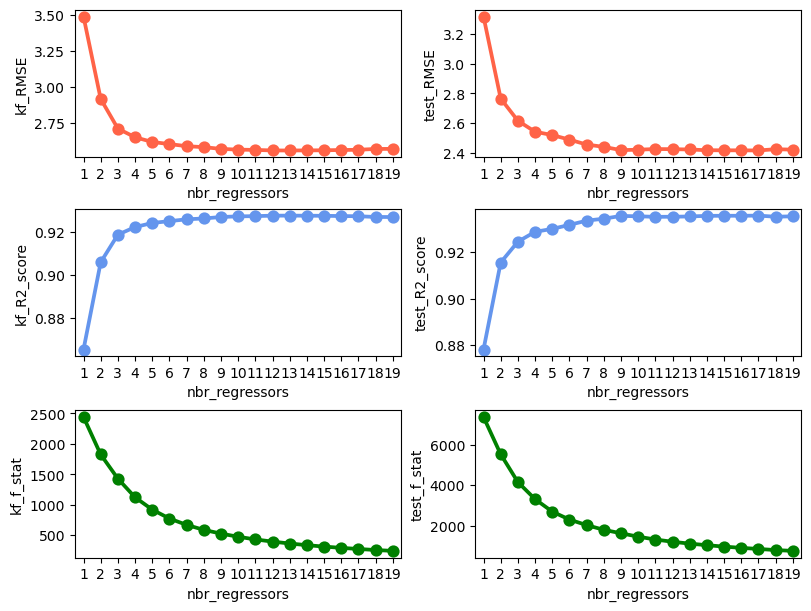

In [59]:
#Evaluate nested models: 

res = [model_validation_multi_regression(
                                        test_size=.35,
                                        split_seed=1234,
                                        cv_seed=54321,
                                        k=5,
                                        nbr_loops=10,
                                        regressors=selected_features[:i],
                                        interaction=False,
                                        use_pca=False,
                                        pcs=None,
                                        scores_only=True)for i in np.arange(1, len(selected_features) + 1)]

df = pd.DataFrame.from_dict(res)

df['nbr_regressors'] = np.arange(1, len(selected_features) + 1)

#Add actual regressors used
regressors_list = []
for i in range(1, len(selected_features) + 1):
    regressors_list.append(selected_features[:i])

df['regressors'] = regressors_list

df = df.sort_values(by=['kf_RMSE', 'kf_R2_score'], ascending=[True, False]).head(20)

fig, ax = plt.subplots(3, 2, figsize=(8, 6), constrained_layout=True)

sns.pointplot(data=df, x='nbr_regressors', y='kf_RMSE', color='tomato', ax=ax[0, 0])
sns.pointplot(data=df, x='nbr_regressors', y='test_RMSE', color='tomato', ax=ax[0, 1])

sns.pointplot(data=df, x='nbr_regressors', y='kf_R2_score', color='cornflowerblue', ax=ax[1, 0])
sns.pointplot(data=df, x='nbr_regressors', y='test_R2_score', color='cornflowerblue', ax=ax[1, 1])

sns.pointplot(data=df, x='nbr_regressors', y='kf_f_stat', color='green', ax=ax[2, 0])
sns.pointplot(data=df, x='nbr_regressors', y='test_f_stat', color='green', ax=ax[2, 1]);


The plots show that model performance greatly improves when the number of regressors increases from 1 to 4. Specifically, RMSE decreases significantly, and R^2 increases quickly within this range.

What’s important to note is that the improvements in RMSE and R^2 after 4 are minimal. I think selecting 4 regressors would produce an optimized model because a simpler model with fewer regressors is less likely to overfit.

In [63]:
final_regressors = selected_features[:4]
print(final_regressors)

['adult_mortality', 'icr', 'hiv_aids', 'gdp']


regressors: ['adult_mortality', 'icr', 'hiv_aids', 'gdp']
k-fold R^2: 0.9220715087359757
k-fold RMSE: 2.650243897273927
k-fold F-stat: 1122.7557370757152
Test R^2: 0.9286124530273894
Test RMSE: 2.541002477616028
Test F-stat: 3317.0515806186204



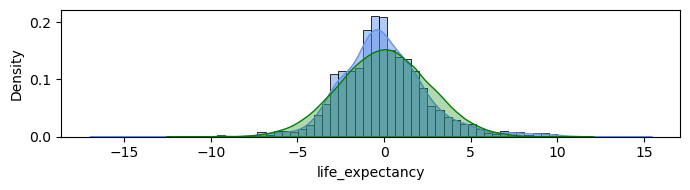

In [64]:
model_validation_multi_regression(
    test_size=.35,
    split_seed=1234,
    cv_seed=54321,
    k=5,
    nbr_loops=10,
    regressors=final_regressors,
    interaction=False,
    use_pca=False,
    pcs=None,
    scores_only=False
)

### The model with interaction terms:

regressors: ['Intercept', 'adult_mortality', 'icr', 'hiv_aids', 'gdp', 'status', 'status:gdp', 'status:hiv_aids']
k-fold R^2: 0.9224346355416165
k-fold RMSE: 2.643969451778002
k-fold F-stat: 558.3345308402298
Test R^2: 0.9286959734707847
Test RMSE: 2.539515609298482
Test F-stat: 1654.1055866244028



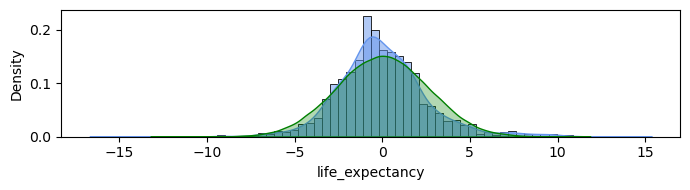

In [62]:
model_validation_multi_regression(
    test_size=.35,
    split_seed=1234,
    cv_seed=54321,
    k=5,
    nbr_loops=10,
    regressors=final_regressors,
    interaction=True,
    use_pca=False,
    pcs=None,
    scores_only=False
)

## 

## An optimized multilinear regression model using PCA

In [65]:
X = reshaped_life_expectancy()
y = X['life_expectancy']
X = X.drop(columns=['life_expectancy'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.35, random_state=12345
)

X_train_pca, X_test_pca, y_train_pca, y_test_pca, regressors_pca = data_preprocessing(
    X_train=X_train.copy(),
    X_test=X_test.copy(),
    y_train=y_train.copy(),
    y_test=y_test.copy(),
    regressors=None, 
    interaction=False, 
    use_pca=True,
    pcs=None
)

In [66]:
# Selecting the pcs being the most correlated to the outcome, the y
pc_ranking = pd.DataFrame(X_train_pca).corrwith(
    y_train_pca.reset_index(drop=True)
).abs().sort_values(ascending=False).index.tolist()

#### Progressive selection based on correlation

,kf_R2_score,kf_RMSE,kf_f_stat,test_R2_score,test_RMSE,test_f_stat,regressors,nbr_pcs
16,0.926802,2.568515,272.986057,0.935170,2.421493,854.460898,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",17
17,0.926750,2.569435,256.886841,0.935298,2.419099,807.896718,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",18
18,0.926742,2.569548,242.681087,0.935257,2.419853,764.105736,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",19
15,0.926730,2.569742,290.528816,0.935119,2.422440,908.006316,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",16
14,0.926420,2.575176,309.322191,0.934680,2.430618,962.536734,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",15
13,0.926031,2.581947,330.342508,0.934572,2.432635,1030.480518,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10]",14
12,0.925115,2.598164,351.681469,0.933346,2.455314,1088.990424,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11]",13
11,0.924007,2.617333,375.853260,0.933675,2.449251,1187.178325,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5]",12
10,0.921334,2.662427,396.381168,0.931747,2.484596,1257.160775,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17]",11
9,0.916898,2.736414,412.023781,0.926576,2.576994,1279.616786,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9]",10


<Axes: xlabel='n_components', ylabel='test_f_stat'>

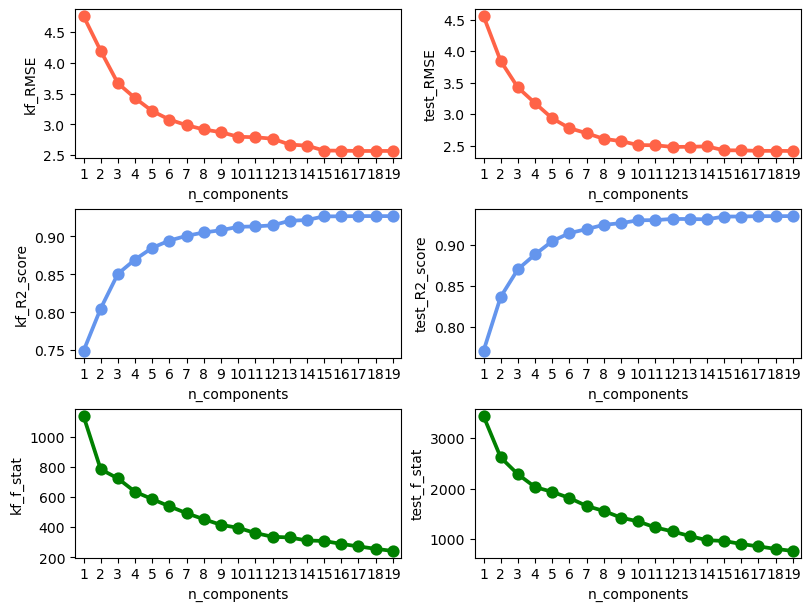

In [67]:
res = [
    model_validation_multi_regression(
        test_size=.35,
        split_seed=1234,
        cv_seed=54321,
        k=5,
        nbr_loops=10,
        regressors=None,
        interaction=False,
        use_pca=True,
        pcs=pc_ranking[:i],
        scores_only=True
    )
    for i in np.arange(1, len(pc_ranking) + 1)
]

df = pd.DataFrame.from_dict(res)\
    .assign(n_components=np.arange(1, len(pc_ranking) + 1))

display(df_pca.sort_values(by=['kf_RMSE', 'kf_R2_score'], ascending=[True, False]).head(20))

#fig, ax = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
#plt.rcParams["figure.figsize"] = [10, 6]
#plt.rcParams["figure.autolayout"] = True

fig, ax = plt.subplots(3, 2, figsize=(8, 6), constrained_layout=True)


sns.pointplot(data=df, x='n_components', y='kf_RMSE', color='tomato', ax=ax[0, 0])
sns.pointplot(data=df, x='n_components', y='test_RMSE', color='tomato', ax=ax[0, 1])

sns.pointplot(data=df, x='n_components', y='kf_R2_score',color='cornflowerblue', ax=ax[1, 0])
sns.pointplot(data=df, x='n_components', y='test_R2_score', color='cornflowerblue',ax=ax[1, 1])

sns.pointplot(data=df, x='n_components', y='kf_f_stat',color='green', ax=ax[2, 0])
sns.pointplot(data=df, x='n_components', y='test_f_stat', color='green', ax=ax[2, 1])


It is clear from the plots that kf_R^2 rapidly increases from n_components = 1 to 14. Beyond 14, the R^2 seems to fluctuate slightly. Similarly, kf_RMSE decreases significantly from 1 to 14, and the change after 14 is not obvious. I believe n_components = 14 is an optimal value because kf_R^2 improves little beyond 14, and having too many principal components will make the model
too complicated and increase the risk of overfitting.

Therefore, I selected 14 components and examined the corresponding model validation results.

regressors: [0, 2, 3, 6, 14, 12, 1, 17, 5, 9, 8, 10, 4, 11]
k-fold R^2: 0.9216304192200353
k-fold RMSE: 2.655210463397314
k-fold F-stat: 312.37086854952037
Test R^2: 0.9312874554621886
Test RMSE: 2.492940279754076
Test F-stat: 977.779797128199



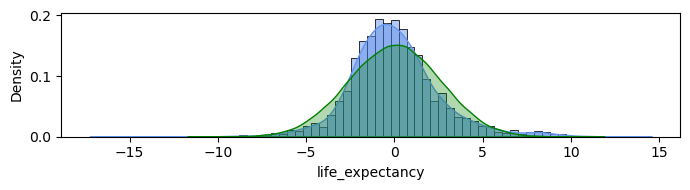

In [33]:
model_validation_multi_regression(
    test_size=.35,
    split_seed=1234,
    cv_seed=54321,
    k=5,
    nbr_loops=10,
    regressors=None,
    interaction=False,
    use_pca=True,
    pcs=pc_ranking[:14],
    scores_only=False 
)

### Exhaustive progressive selection 

In [12]:
# PCA exhaustive progressive selection
features = [k for k in np.arange(0, 19)]
selected_features = []

# At each step, try adding each remaining PC, and keep the one that gives the lowest k-fold RMSE
while len(features) > 0:
    
    all_res = []
    
    for pc in features:
        combination = selected_features.copy()
        combination.append(pc)
        
        res = model_validation_multi_regression(
            test_size=.35,
            split_seed=1234,
            cv_seed=54321,
            k=5,
            nbr_loops=3,
            regressors=None,
            interaction=False,
            use_pca=True,
            pcs=combination,
            scores_only=True
        )
        
        all_res.append(res)
    
    added_pc = pd.DataFrame.from_dict(all_res)\
        .assign(added_pc=features)\
        .sort_values(by='kf_RMSE', ascending=True)\
        .iloc[0, :].loc['added_pc']
    
    selected_features.append(added_pc)
    features.remove(added_pc)
   

In [13]:
# Evaluate nested PCA models
res_pca = [
    model_validation_multi_regression(
        test_size=.35,
        split_seed=12345,
        cv_seed=54321,
        k=5,
        nbr_loops=10,
        regressors=None,
        interaction=False,
        use_pca=True,
        pcs=selected_features[:i],
        scores_only=True
    )
    for i in np.arange(1, len(selected_features) + 1)
]

df_pca = pd.DataFrame.from_dict(res_pca)\
    .assign(nbr_pcs=np.arange(1, len(selected_features) + 1))\
    .sort_values(by=['kf_RMSE', 'kf_R2_score'], ascending=[True, False])

display(df_pca.head(20))

,kf_R2_score,kf_RMSE,kf_f_stat,test_R2_score,test_RMSE,test_f_stat,regressors,nbr_pcs
16,0.926802,2.568515,272.986057,0.935170,2.421493,854.460898,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",17
17,0.926750,2.569435,256.886841,0.935298,2.419099,807.896718,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",18
18,0.926742,2.569548,242.681087,0.935257,2.419853,764.105736,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",19
15,0.926730,2.569742,290.528816,0.935119,2.422440,908.006316,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",16
14,0.926420,2.575176,309.322191,0.934680,2.430618,962.536734,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10...",15
13,0.926031,2.581947,330.342508,0.934572,2.432635,1030.480518,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11, 10]",14
12,0.925115,2.598164,351.681469,0.933346,2.455314,1088.990424,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5, 11]",13
11,0.924007,2.617333,375.853260,0.933675,2.449251,1187.178325,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17, 5]",12
10,0.921334,2.662427,396.381168,0.931747,2.484596,1257.160775,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9, 17]",11
9,0.916898,2.736414,412.023781,0.926576,2.576994,1279.616786,"[0, 2, 3, 6, 14, 12, 1, 4, 7, 9]",10


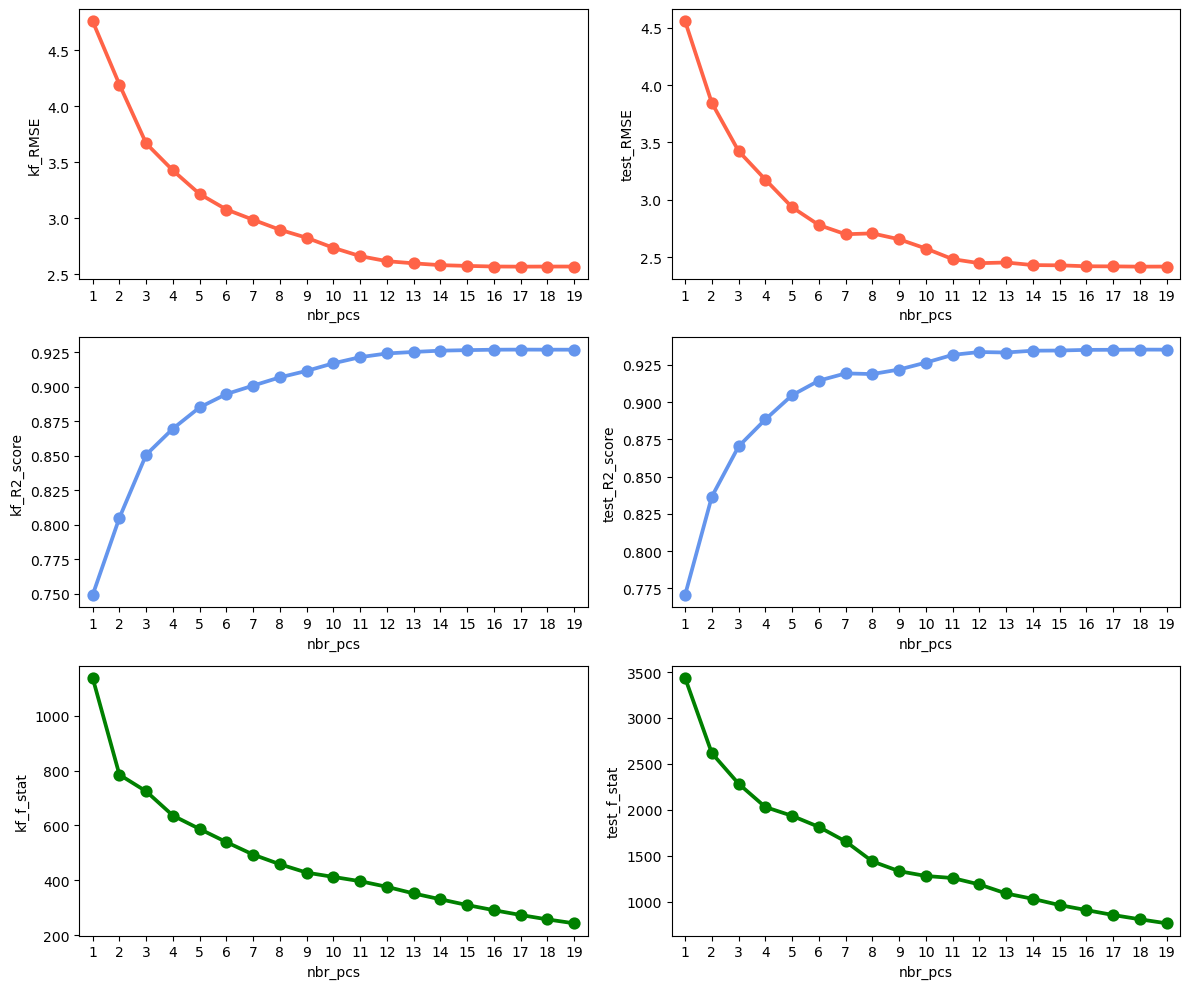

In [14]:
fig, ax = plt.subplots(3, 2, figsize=(12, 10))
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.autolayout"] = True

sns.pointplot(data=df_pca, x='nbr_pcs', y='kf_RMSE', color='tomato', ax=ax[0, 0])
sns.pointplot(data=df_pca, x='nbr_pcs', y='test_RMSE', color='tomato', ax=ax[0, 1])

sns.pointplot(data=df_pca, x='nbr_pcs', y='kf_R2_score', color='cornflowerblue', ax=ax[1, 0])
sns.pointplot(data=df_pca, x='nbr_pcs', y='test_R2_score', color='cornflowerblue', ax=ax[1, 1])

sns.pointplot(data=df_pca, x='nbr_pcs', y='kf_f_stat', color='green', ax=ax[2, 0])
sns.pointplot(data=df_pca, x='nbr_pcs', y='test_f_stat', color='green', ax=ax[2, 1]);

The exhaustive progressive selection presents the same plotting result as the progressive selection based on correlation. I believe this is because principal components are orthogonal. As a result, selecting components by their correlation with the response and selecting them progressively based on model improvement contributed to the same ordering of components and therefore the same performance metric curves.